# Notebook 03: Qualidade Lógica e Completude — A Integridade dos Dados

**Novidade**: Incorporamos os **polígonos oficiais dos bairros de BH** (Prodabel).

In [1]:
import sys, os, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import folium
import contextily as ctx

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config
from src.metrics import calculate_lci, calculate_completude

gdf_matched = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_matched.parquet')
gdf_bairros = gpd.read_file(config.BAIRROS_SHP)


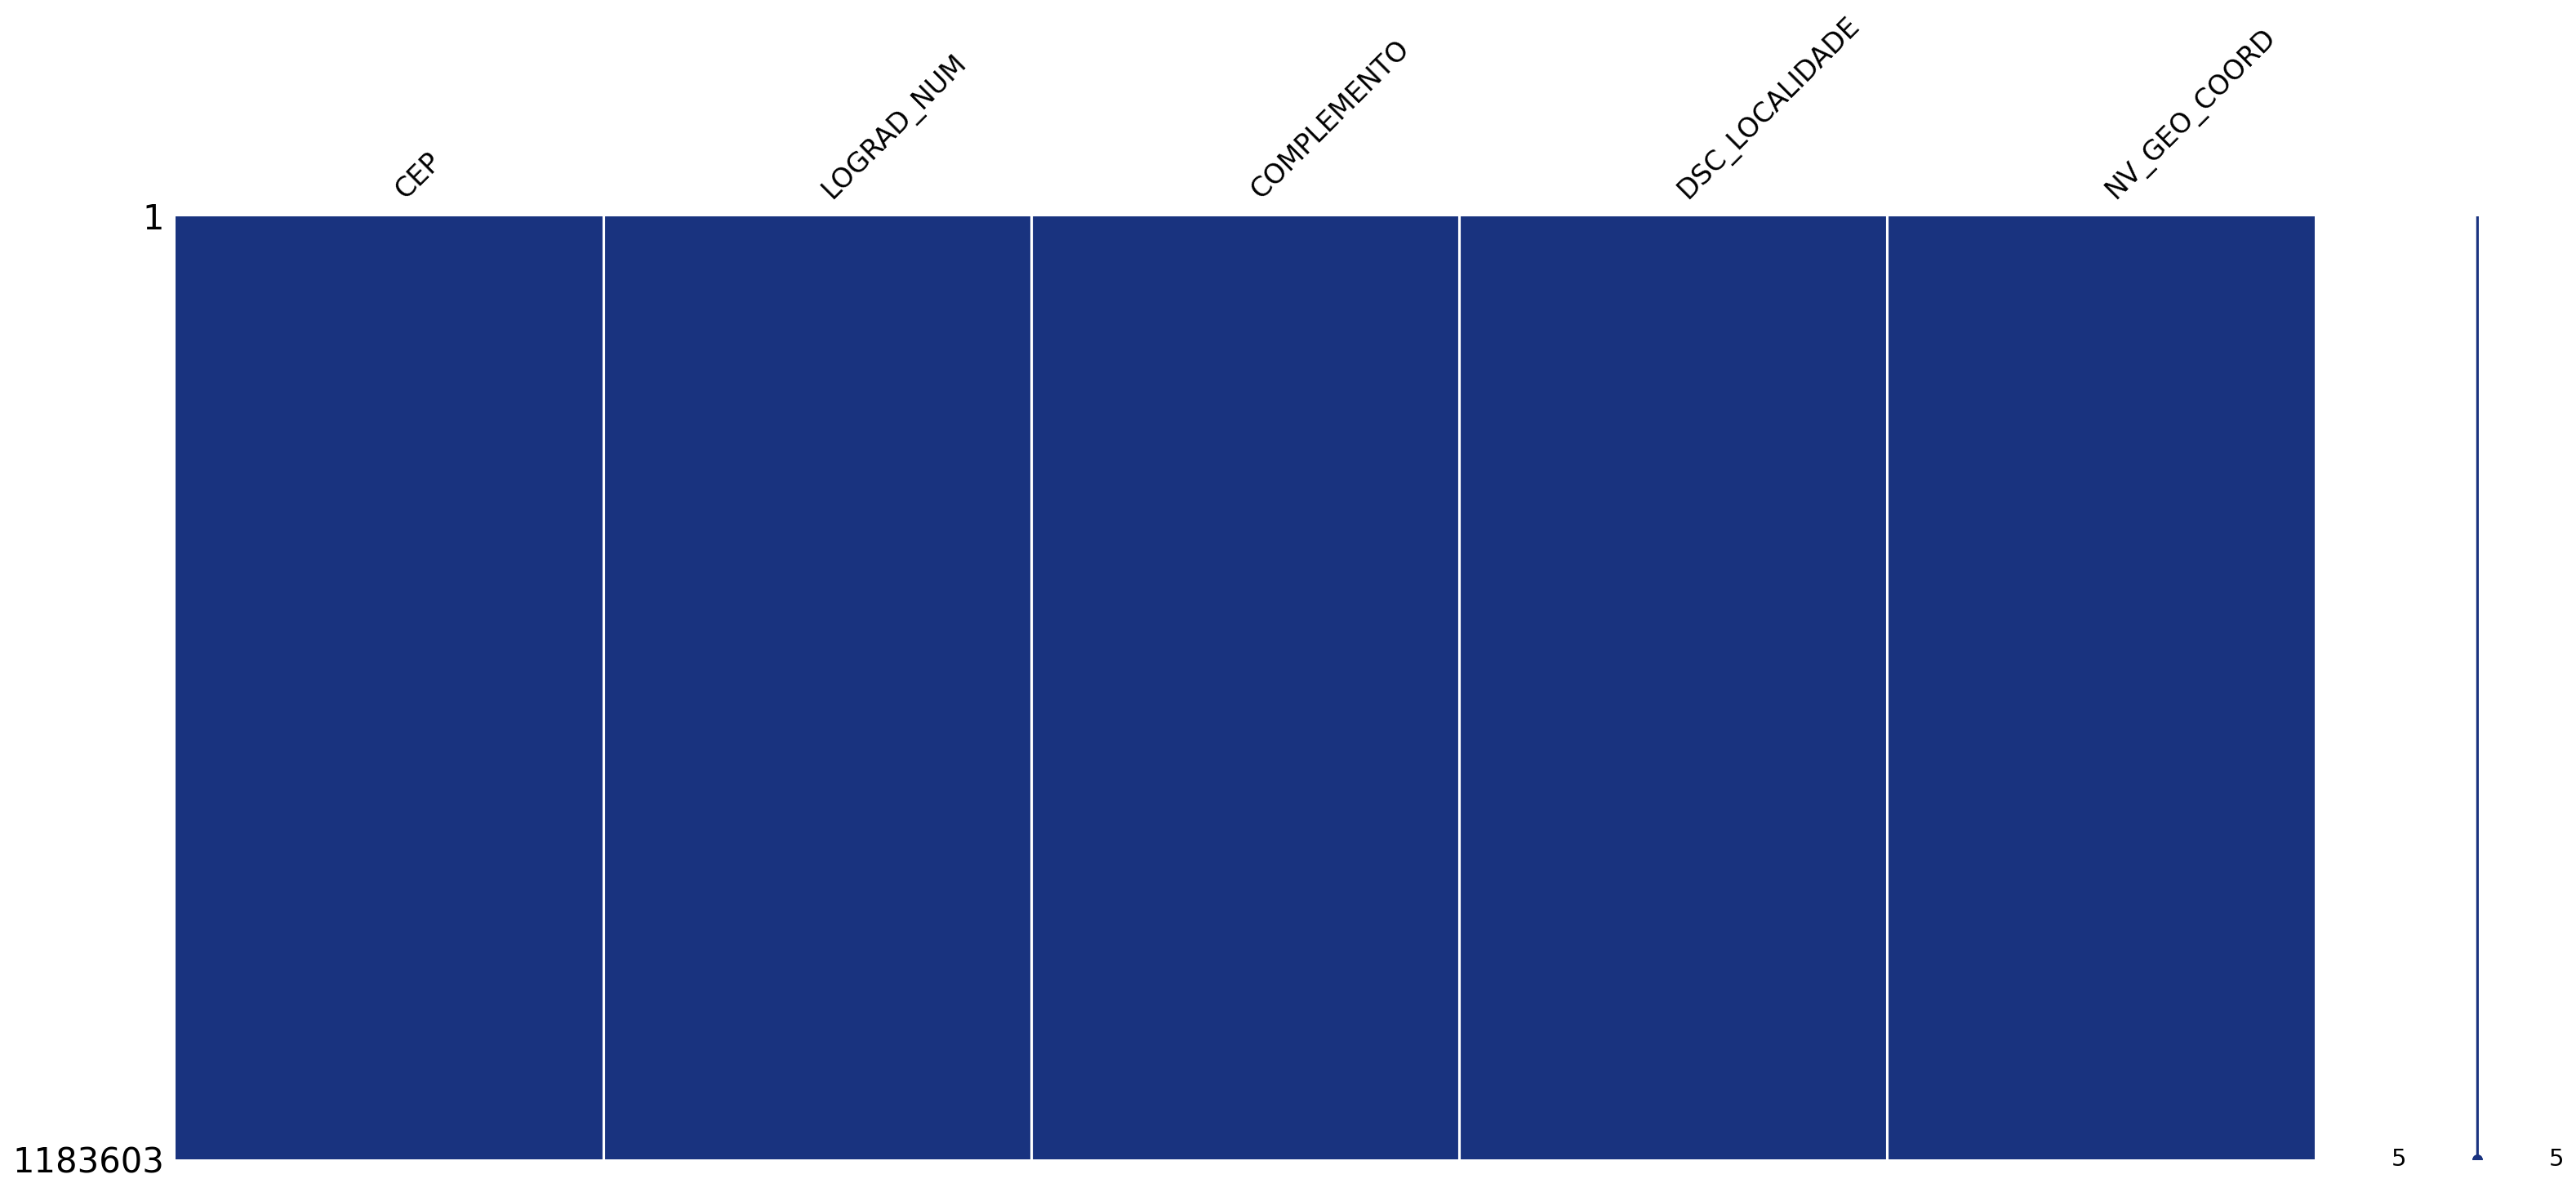

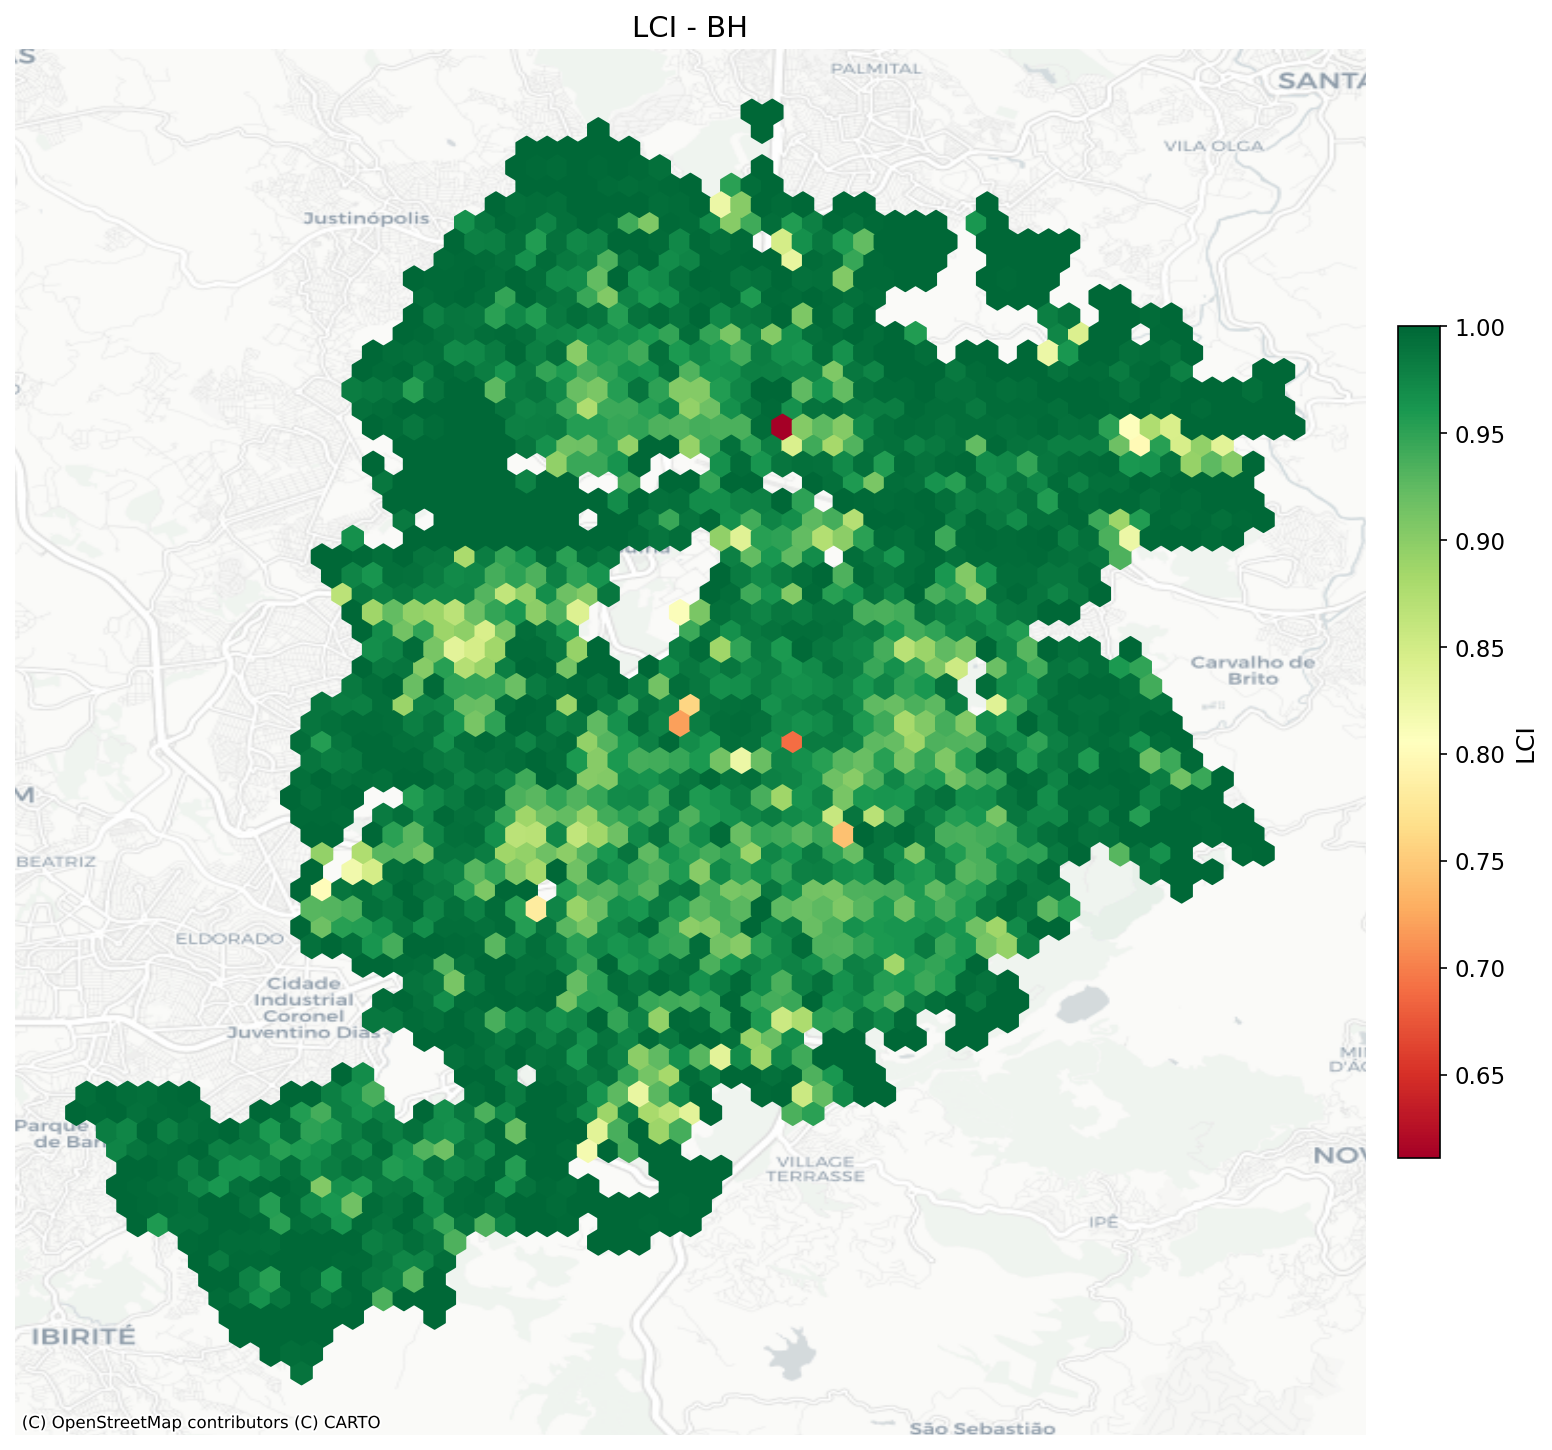

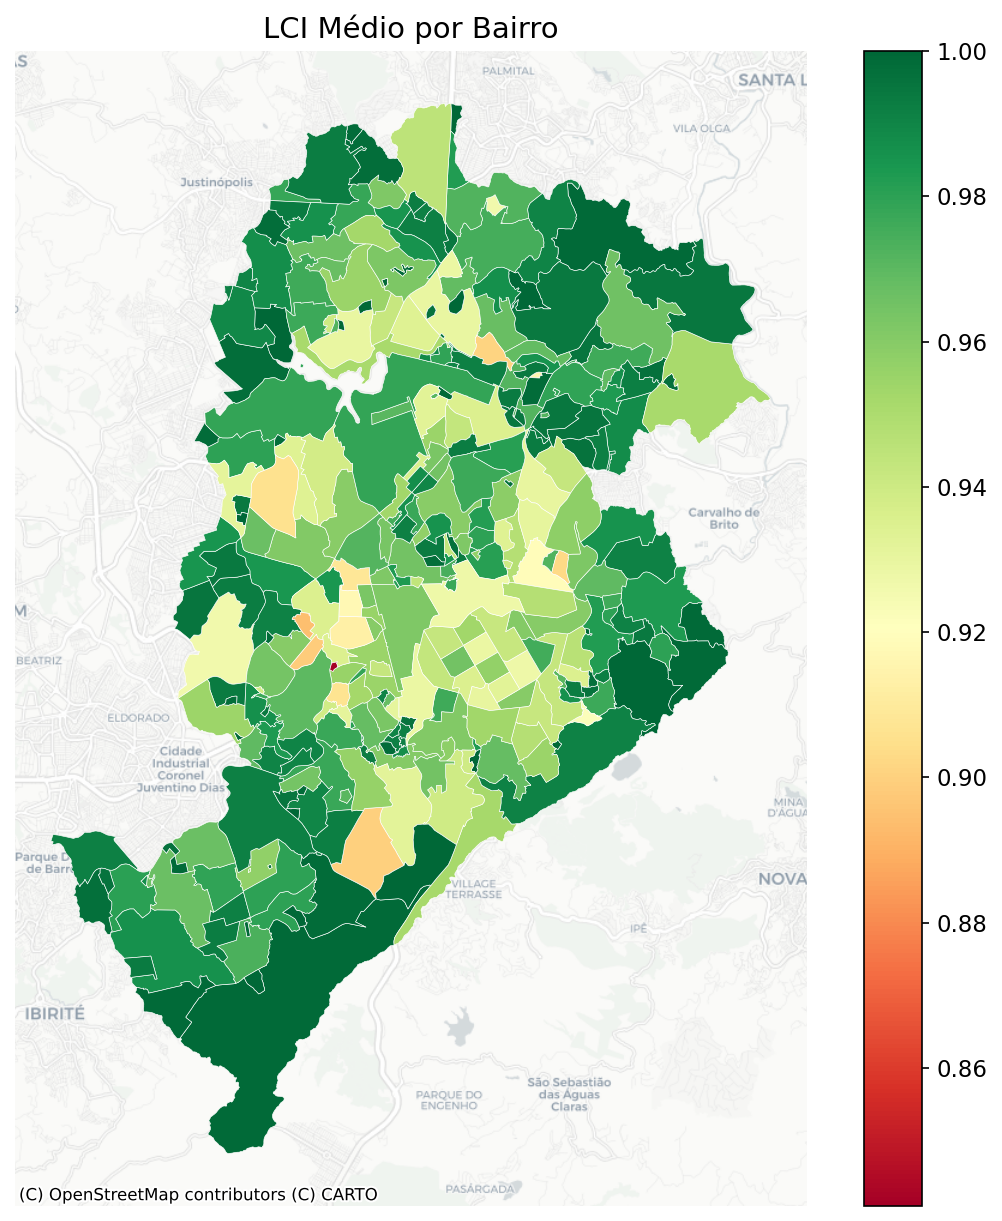

In [2]:
# Calcular métricas
gdf_matched['COMPLETUDE'] = calculate_completude(gdf_matched)
gdf_matched['LCI'] = calculate_lci(gdf_matched['NV_GEO_COORD'])

# Matriz de nulidade
msno.matrix(gdf_matched[[c for c in config.COMPLETUDE_CAMPOS_PESOS.keys() if c in gdf_matched.columns]], color=(0.1, 0.2, 0.5))
plt.savefig(config.FIG_DIR / '03_matrix_nulidade.png', dpi=200, bbox_inches='tight')
plt.show()

# Hexbin LCI
from src.spatial import plot_hexbin_metric
plot_hexbin_metric(gdf_matched, 'LCI', title='LCI - BH', cmap='RdYlGn', output_path=config.FIG_DIR / '03_mapa_lci_hexbin.png')
plt.show()

# FIX: Spatial join: pontos CNEFE -> bairros (DROP index_right to avoid ValueError)
gdf_matched = gdf_matched.drop(columns='index_right', errors='ignore')
gdf_with_bairro = gpd.sjoin(gdf_matched, gdf_bairros[['NOME', 'geometry']], how='left', predicate='within')
gdf_with_bairro = gdf_with_bairro.rename(columns={'NOME': 'BAIRRO_OFICIAL'})

lci_bairro = gdf_with_bairro.groupby('BAIRRO_OFICIAL').agg(LCI_mean=('LCI', 'mean'), COMP_mean=('COMPLETUDE', 'mean')).reset_index()
gdf_bairros_lci = gdf_bairros.merge(lci_bairro, left_on='NOME', right_on='BAIRRO_OFICIAL', how='left')

# Coroplético estático
fig, ax = plt.subplots(figsize=(10, 10))
gdf_bairros_lci.to_crs(epsg=3857).plot(column='LCI_mean', cmap='RdYlGn', ax=ax, legend=True, edgecolor='white', linewidth=0.3)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title('LCI Médio por Bairro')
ax.axis('off')
plt.savefig(config.FIG_DIR / '03_coropletico_bairro_lci.png', dpi=200, bbox_inches='tight')
plt.show()

gdf_matched.to_parquet(config.PROCESSED_DIR / 'cnefe_pre_gci.parquet')
